In [1]:
from metrics import truthfulness, cognitive_dissonance

# Quick test
import numpy as np
q = np.random.rand(2,3,4,5)
p = np.random.rand(2,3,4,5)

print(truthfulness(q, 1))
print(cognitive_dissonance(q, p, 1))


[0.295388   0.34735636 0.56131036]
(array([0.36665455, 0.4154032 , 0.30197563]), array([0., 0., 0.]))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from metrics import truthfulness, cognitive_dissonance

row 113 has nan-values
row 141 has nan-values
row 278 has nan-values


Text(0, 0.5, 'Truthfulness, $\\tau$')

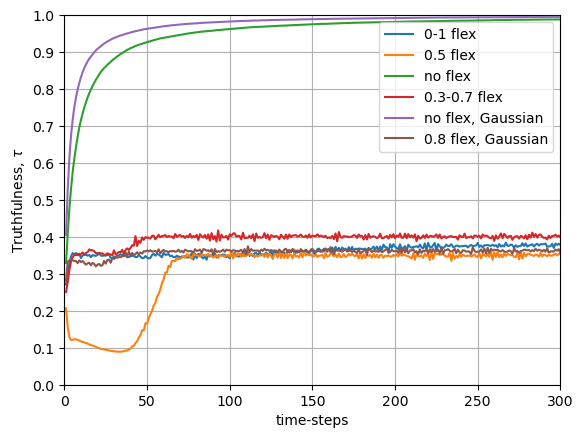

In [ ]:
beliefs_noflex = np.load(r"DHT_k100_ER_no_log_beliefs_T500.npz")
beliefs_05flex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_05flex_500sims.npz")
beliefs_0to1flex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_0to1flex_500sims.npz")
beliefs_03to07flex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_flex_500sims.npz")
beliefs_G = np.load(r"DHT_k100_ER_no_log_beliefs_gaussianX_T300_03to07flex_500sims.npz")
beliefs_G_noflex = np.load(r"DHT_k100_ER_no_log_beliefs_gaussianX_T300_noflex_500sims.npz")
beliefs_08flex = np.load(r"DHT_k100_ER_no_log_beliefs_gaussianX_T300_08flex_500sims.npz")

q_0to1 = beliefs_0to1flex["private"]
q_05 = beliefs_05flex["private"]
q_no = beliefs_noflex["private"]
q_03to07 = beliefs_03to07flex["private"]
q_G = beliefs_G["private"]
q_G_noflex = beliefs_G_noflex["private"]
q_08 = beliefs_08flex["private"]

remove = np.where(np.isnan(q_05[:, -1]))
# print(remove)
new_q = np.delete(q_05, remove, axis=0)
# print(new_q.shape)

for i, q in enumerate(q_05):
    if np.any(np.isnan(q)):
        print(f"row {i} has nan-values")

T_one_sim = np.mean(q_05[0, :, :, 3], axis=1)
T_0to1 = truthfulness(q_0to1, 3)
T_05 = truthfulness(new_q, 3)
T_no = truthfulness(q_no, 3)
T_03to07 = truthfulness(q_03to07, 3)
T_G = truthfulness(q_G, 3)
T_G_noflex = truthfulness(q_G_noflex, 3)
T_08 = truthfulness(q_08, 3)

t = np.arange(1, len(T_0to1))
# print(T_one_sim)

plt.figure()
plt.plot(t, T_0to1[1::], label=r"0-1 flex", zorder=2)
plt.plot(t, T_05[1::], label=r"0.5 flex", zorder=3)
plt.plot(t, T_no[1:len(t)+1], label=r"no flex", zorder=4)
plt.plot(t, T_03to07[1::], label=r"0.3-0.7 flex", zorder=5)
# plt.plot(t, T_one_sim[1::], label="one example 0.3-0.7 flex", zorder=1)
# plt.plot(t, T_G[1::], label=r"0.3-0.7 flex, Gaussian", zorder=6)
plt.plot(t, T_G_noflex[1::], label=r"no flex, Gaussian", zorder=7)
plt.plot(t, T_08[1::], label=r"0.8 flex, Gaussian", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")

Text(0, 0.5, 'Truthfulness, $\\tau$')

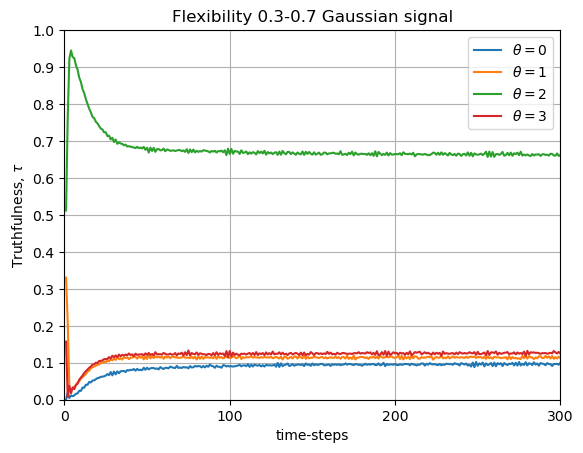

In [ ]:
beliefsflex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_08flex_500sims.npz")

q = beliefsflex["private"]
remove = np.where(np.isnan(q[:, -1]))
q = np.delete(q, remove, axis=0)
T0 = truthfulness(q, 0)
T1 = truthfulness(q, 1)
T2 = truthfulness(q, 2)
T3 = truthfulness(q, 3)
t = np.arange(1, len(T0))

plt.figure()
plt.plot(t, T0[1::], label=r"$\theta=0$", zorder=2)
plt.plot(t, T1[1::], label=r"$\theta=1$", zorder=3)
plt.plot(t, T2[1::], label=r"$\theta=2$", zorder=4)
plt.plot(t, T3[1::], label=r"$\theta=3$", zorder=5)
# plt.plot(t, T_one_sim[1::], label="one example 0.3-0.7 flex", zorder=1)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 100))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.title("Flexibility 0.3-0.7 Gaussian signal")
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")

Text(0, 0.5, 'Truthfulness, $\\tau$')

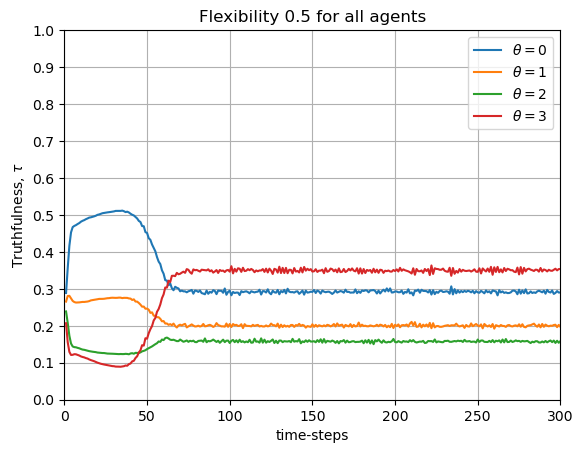

In [ ]:
beliefsflex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_05flex_500sims.npz")

q = beliefsflex["private"]
remove = np.where(np.isnan(q[:, -1]))
q = np.delete(q, remove, axis=0)
T0 = truthfulness(q, 0)
T1 = truthfulness(q, 1)
T2 = truthfulness(q, 2)
T3 = truthfulness(q, 3)

plt.figure()
plt.plot(t, T0[1::], label=r"$\theta=0$", zorder=2)
plt.plot(t, T1[1::], label=r"$\theta=1$", zorder=3)
plt.plot(t, T2[1:len(t)+1], label=r"$\theta=2$", zorder=4)
plt.plot(t, T3[1::], label=r"$\theta=3$", zorder=5)
# plt.plot(t, T_one_sim[1::], label="one example 0.3-0.7 flex", zorder=1)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.title("Flexibility 0.5 for all agents")
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")

Text(0, 0.5, 'Truthfulness, $\\tau$')

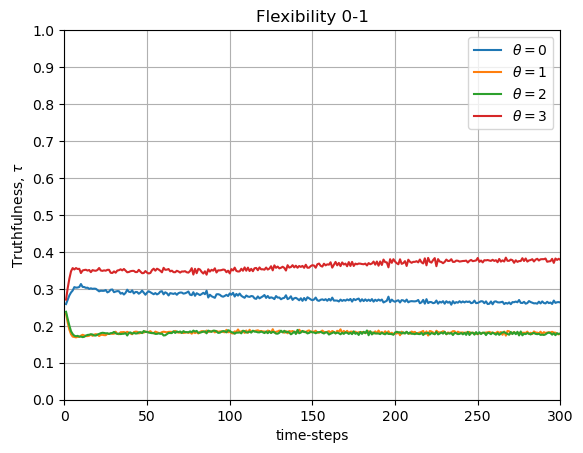

In [ ]:
beliefsflex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_0to1flex_500sims.npz")

q = beliefsflex["private"]
remove = np.where(np.isnan(q[:, -1]))
q = np.delete(q, remove, axis=0)
T0 = truthfulness(q, 0)
T1 = truthfulness(q, 1)
T2 = truthfulness(q, 2)
T3 = truthfulness(q, 3)

plt.figure()
plt.plot(t, T0[1::], label=r"$\theta=0$", zorder=2)
plt.plot(t, T1[1::], label=r"$\theta=1$", zorder=3)
plt.plot(t, T2[1:len(t)+1], label=r"$\theta=2$", zorder=4)
plt.plot(t, T3[1::], label=r"$\theta=3$", zorder=5)
# plt.plot(t, T_one_sim[1::], label="one example 0.3-0.7 flex", zorder=1)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.title("Flexibility 0-1")
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")

Text(0, 0.5, 'Truthfulness, $\\tau$')

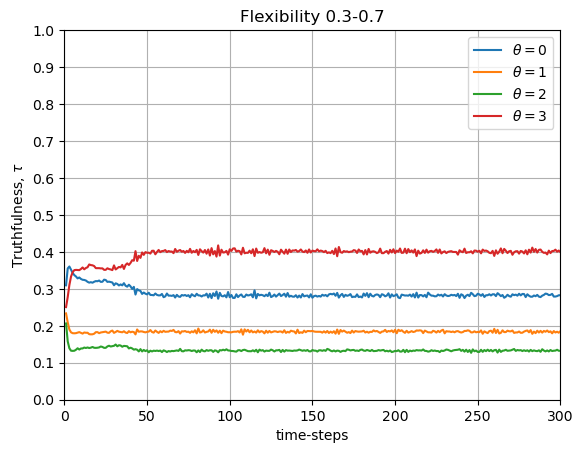

In [ ]:
beliefsflex = np.load(r"DHT_k100_ER_no_log_beliefs_T300_flex_500sims.npz")

q = beliefsflex["private"]
remove = np.where(np.isnan(q[:, -1]))
q = np.delete(q, remove, axis=0)
T0 = truthfulness(q, 0)
T1 = truthfulness(q, 1)
T2 = truthfulness(q, 2)
T3 = truthfulness(q, 3)

plt.figure()
plt.plot(t, T0[1::], label=r"$\theta=0$", zorder=2)
plt.plot(t, T1[1::], label=r"$\theta=1$", zorder=3)
plt.plot(t, T2[1:len(t)+1], label=r"$\theta=2$", zorder=4)
plt.plot(t, T3[1::], label=r"$\theta=3$", zorder=5)
# plt.plot(t, T_one_sim[1::], label="one example 0.3-0.7 flex", zorder=1)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.title("Flexibility 0.3-0.7")
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")

Text(0, 0.5, 'Truthfulness, $\\tau$')

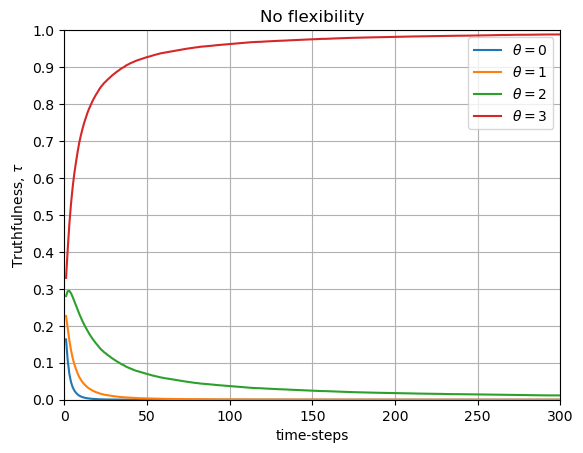

In [ ]:
beliefsflex = np.load(r"DHT_k100_ER_no_log_beliefs_T500.npz")

q = beliefsflex["private"]
remove = np.where(np.isnan(q[:, -1]))
q = np.delete(q, remove, axis=0)
T0 = truthfulness(q, 0)
T1 = truthfulness(q, 1)
T2 = truthfulness(q, 2)
T3 = truthfulness(q, 3)

plt.figure()
plt.plot(t, T0[1:len(t)+1], label=r"$\theta=0$", zorder=2)
plt.plot(t, T1[1:len(t)+1], label=r"$\theta=1$", zorder=3)
plt.plot(t, T2[1:len(t)+1], label=r"$\theta=2$", zorder=4)
plt.plot(t, T3[1:len(t)+1], label=r"$\theta=3$", zorder=5)
# plt.plot(t, T_one_sim[1::], label="one example 0.3-0.7 flex", zorder=1)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.title("No flexibility")
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")